In [1]:
%load_ext autoreload
%autoreload 3

In [2]:
import numpy as np
from collections import Counter
import math
import pandas as pd
import matplotlib.pyplot as plt
from methods import (CriterionNode, HierarchicalElectreTriB, set_equal_weights_topdown, class_acceptability_smaa, 
                     plot_country_pies_smaa, plot_acceptability_smaa, params_to_df, country_hierarchy, compute_lambdas)

In [3]:
raw = pd.read_csv("Freedom_and_Prosperity.csv", decimal=",")
print(f"Raw data: {raw.shape[0]} rows x {raw.shape[1]} columns")

# criteria
leaf_cols = [
    # Economic subindex
    "Proper_Rights", "Trade_Freedom", "Investm_Freedom", "Womens_Economic_Freedom",
    # Political subindex
    "PF_Elections", "Civil_Liberties", "Political_Rights", "Legislative_Constraints_on_the_Executive",
    # Legal subindex
    "Clarity_of_the_Law", "Judicial_Independence_and_Effectiveness", "Bureaucracy_and_Corruption",
    "Security", "Informality",
    # Prosperity
    "Income", "Environment", "Minorities", "Health", "Education", "Inequality",
]

# Keep only countries and only the year 2024
df = raw[(raw["Index_Year"] == 2024) & (raw["ISO3"].notna())].copy()
print(f"Countries in 2024: {df.shape[0]}")

# Drop countries with missing values in the elementary criteria
df = df.dropna(subset=leaf_cols)
print(f"Complete countries (no missing values): {df.shape[0]}")

# Keep only the criteria columns, indexed by country name
df = df.set_index("Name")[leaf_cols]
print(f"\n{df.shape[0]} countries x {df.shape[1]} criteria")

df.head()

Raw data: 5610 rows x 57 columns
Countries in 2024: 164
Complete countries (no missing values): 151

151 countries x 19 criteria


,Proper_Rights,Trade_Freedom,Investm_Freedom,Womens_Economic_Freedom,PF_Elections,Civil_Liberties,Political_Rights,Legislative_Constraints_on_the_Executive,Clarity_of_the_Law,Judicial_Independence_and_Effectiveness,Bureaucracy_and_Corruption,Security,Informality,Income,Environment,Minorities,Health,Education,Inequality
Name,,,,,,,,,,,,,,,,,,,
Angola,33.909381,33.410951,30.0,79.375,76.466667,64.30,55.35,17.2,45.983607,44.040167,29.926194,57.477784,56.946183,50.147485,60.720898,41.396151,63.271312,50.720767,36.342593
Albania,44.205751,93.027856,60.0,91.250,82.900000,93.25,75.90,68.2,57.076503,70.222170,45.890337,68.104440,73.091364,65.245762,70.600380,59.442325,90.660184,73.716172,63.657407
United Arab Emirates,76.338100,88.628857,50.0,82.500,29.866667,46.30,5.25,13.8,66.543716,39.614388,75.545517,78.110082,79.224030,87.491842,76.744827,51.453732,96.704562,87.557582,80.324074
Argentina,47.924284,43.020571,65.0,79.375,95.733333,87.60,81.15,81.6,53.524590,69.624609,39.167640,61.810356,71.214018,72.069277,74.537699,74.048145,86.626334,88.536107,63.657407
Armenia,54.473859,85.140215,70.0,90.625,89.233333,82.20,80.95,61.0,59.986339,48.077975,45.870747,47.601900,56.445557,66.366509,69.386882,62.291859,83.497222,77.623469,72.222222


In [44]:
df.loc["Denmark"]

Proper_Rights                                91.674050
Trade_Freedom                                90.131569
Investm_Freedom                              90.000000
Womens_Economic_Freedom                     100.000000
PF_Elections                                 98.633333
Civil_Liberties                              95.450000
Political_Rights                             95.800000
Legislative_Constraints_on_the_Executive     96.900000
Clarity_of_the_Law                           93.620219
Judicial_Independence_and_Effectiveness      95.251234
Bureaucracy_and_Corruption                   94.438746
Security                                     81.619211
Informality                                  93.617021
Income                                       88.159633
Environment                                  80.246309
Minorities                                   97.116352
Health                                       94.920676
Education                                    95.324792
Inequality

In [4]:
Economic = CriterionNode("Economic_Subindex",
                         children=[
                             CriterionNode("Proper_Rights", leaf_id="Proper_Rights"),
                             CriterionNode("Trade_Freedom", leaf_id="Trade_Freedom"),
                             CriterionNode("Investm_Freedom", leaf_id="Investm_Freedom"),
                             CriterionNode("Womens_Economic_Freedom", leaf_id="Womens_Economic_Freedom"),
                         ])

Political = CriterionNode("Political_Subindex",
                          children=[
                              CriterionNode("PF_Elections", leaf_id="PF_Elections"),
                              CriterionNode("Civil_Liberties", leaf_id="Civil_Liberties"),
                              CriterionNode("Political_Rights", leaf_id="Political_Rights"),
                              CriterionNode("Legislative_Constraints_on_the_Executive",
                                            leaf_id="Legislative_Constraints_on_the_Executive"),
                          ])

Legal = CriterionNode("Legal_Subindex",
                      children=[
                          CriterionNode("Clarity_of_the_Law", leaf_id="Clarity_of_the_Law"),
                          CriterionNode("Judicial_Independence_and_Effectiveness",
                                        leaf_id="Judicial_Independence_and_Effectiveness"),
                          CriterionNode("Bureaucracy_and_Corruption", leaf_id="Bureaucracy_and_Corruption"),
                          CriterionNode("Security", leaf_id="Security"),
                          CriterionNode("Informality", leaf_id="Informality"),
                      ])

Freedom = CriterionNode("Freedom",
                        children=[Economic, Political, Legal])

Prosperity = CriterionNode("Prosperity",
                           children=[
                               CriterionNode("Income", leaf_id="Income"),
                               CriterionNode("Environment", leaf_id="Environment"),
                               CriterionNode("Minorities", leaf_id="Minorities"),
                               CriterionNode("Health", leaf_id="Health"),
                               CriterionNode("Education", leaf_id="Education"),
                               CriterionNode("Inequality", leaf_id="Inequality"),
                           ])

Root = CriterionNode("Freedom_and_Prosperity",
                     children=[Freedom, Prosperity])

In [5]:
leaves = Root.leaves()
print(f"{len(leaves)} elementary criteria (leaves):")
print(leaves)

19 elementary criteria (leaves):
['Proper_Rights', 'Trade_Freedom', 'Investm_Freedom', 'Womens_Economic_Freedom', 'PF_Elections', 'Civil_Liberties', 'Political_Rights', 'Legislative_Constraints_on_the_Executive', 'Clarity_of_the_Law', 'Judicial_Independence_and_Effectiveness', 'Bureaucracy_and_Corruption', 'Security', 'Informality', 'Income', 'Environment', 'Minorities', 'Health', 'Education', 'Inequality']


In [6]:
weights = set_equal_weights_topdown(Root, 1.0)

print("weights per leaf:")
for lf in leaves:
    print(f"  {lf:42s} w = {weights[lf]:.4f}")
print(f"\nsum Freedom    = {sum(weights[lf] for lf in Freedom.leaves()):.4f}")
print(f"sum Prosperity = {sum(weights[lf] for lf in Prosperity.leaves()):.4f}")
for sub in (Economic, Political, Legal):
    print(f"sum {sub.name:18s} = {sum(weights[lf] for lf in sub.leaves()):.4f}")

weights per leaf:
  Proper_Rights                              w = 0.0417
  Trade_Freedom                              w = 0.0417
  Investm_Freedom                            w = 0.0417
  Womens_Economic_Freedom                    w = 0.0417
  PF_Elections                               w = 0.0417
  Civil_Liberties                            w = 0.0417
  Political_Rights                           w = 0.0417
  Legislative_Constraints_on_the_Executive   w = 0.0417
  Clarity_of_the_Law                         w = 0.0333
  Judicial_Independence_and_Effectiveness    w = 0.0333
  Bureaucracy_and_Corruption                 w = 0.0333
  Security                                   w = 0.0333
  Informality                                w = 0.0333
  Income                                     w = 0.0833
  Environment                                w = 0.0833
  Minorities                                 w = 0.0833
  Health                                     w = 0.0833
  Education                   

In [7]:
q = {lf: 4.0 for lf in leaves}
p = {lf: 6.0 for lf in leaves}
v = {lf: 40.0 for lf in leaves}

lambda_frac = 0.75
lambdas = compute_lambdas(Root, weights, lambda_frac)

print("lambdas per node:")
for name, lam in lambdas.items():
    print(f"  {name:42s} lambda = {lam:.4f}")

categories = ["Class_1", "Class_2", "Class_3", "Class_4"]  # Class_4 is the best
b1 = {lf: 40.0 for lf in leaves}  # boundary profile between Class_1 and Class_2
b2 = {lf: 60.0 for lf in leaves}  # boundary profile between Class_2 and Class_3
b3 = {lf: 80.0 for lf in leaves}  # boundary profile between Class_3 and Class_4
profiles = {"b1": b1, "b2": b2, "b3":b3}

lambdas per node:
  Freedom_and_Prosperity                     lambda = 0.7500
  Freedom                                    lambda = 0.3750
  Economic_Subindex                          lambda = 0.1250
  Political_Subindex                         lambda = 0.1250
  Legal_Subindex                             lambda = 0.1250
  Prosperity                                 lambda = 0.3750


In [8]:
model = HierarchicalElectreTriB(
    root=Root,
    weights=weights,
    q=q,
    p=p,
    v=v,
    lambdas=lambdas,
    profiles=profiles,
    categories=categories,
    relation="O3")

In [9]:
def classify(procedure):
    alternatives_dict = {}
    for alternative_name in df.index:
        alt = df.loc[alternative_name].to_dict()
        alternatives_dict[alternative_name] = model.assign_all_nodes(alt, procedure=procedure)
    return pd.DataFrame(alternatives_dict).T


res_pess = classify("pessimistic")

# order the columns
node_order = list(lambdas.keys())
res_pess = res_pess[node_order]
res_pess

,Freedom_and_Prosperity,Freedom,Economic_Subindex,Political_Subindex,Legal_Subindex,Prosperity
Angola,Class_2,Class_1,Class_1,Class_1,Class_2,Class_2
Albania,Class_3,Class_3,Class_2,Class_3,Class_2,Class_3
United Arab Emirates,Class_2,Class_1,Class_3,Class_1,Class_2,Class_3
Argentina,Class_3,Class_2,Class_2,Class_4,Class_2,Class_3
Armenia,Class_3,Class_2,Class_3,Class_3,Class_2,Class_3
...,...,...,...,...,...,...
Vietnam,Class_2,Class_1,Class_3,Class_1,Class_2,Class_3
Yemen,Class_1,Class_1,Class_1,Class_1,Class_1,Class_1
South Africa,Class_2,Class_2,Class_2,Class_4,Class_2,Class_1
Zambia,Class_2,Class_2,Class_2,Class_4,Class_2,Class_2


Distribution in the global class (Freedom_and_Prosperity):
Freedom_and_Prosperity
Class_1    30
Class_2    59
Class_3    33
Class_4    29
Name: count, dtype: int64


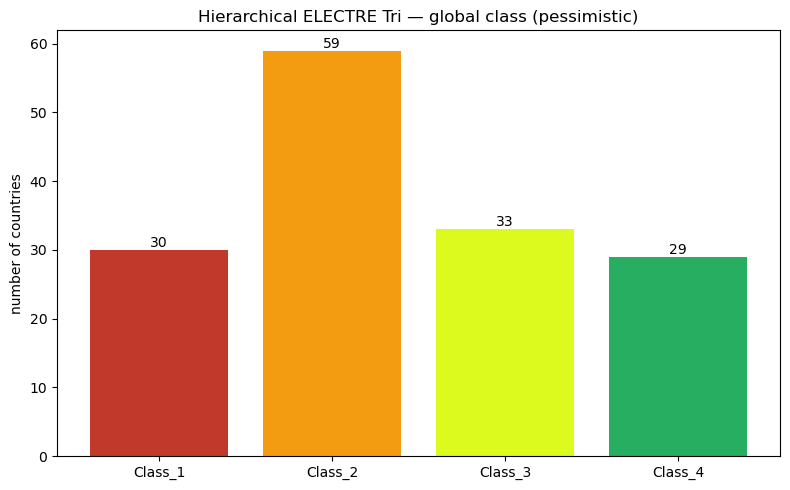

In [10]:
class_counts = res_pess["Freedom_and_Prosperity"].value_counts().reindex(categories, fill_value=0)
print("Distribution in the global class (Freedom_and_Prosperity):")
print(class_counts)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(class_counts.index, class_counts.values, color=["#c0392b", "#f39c12", "#ddfa1f", "#27ae60"])
ax.set_ylabel("number of countries")
ax.set_title("Hierarchical ELECTRE Tri — global class (pessimistic)")
for x, y in zip(class_counts.index, class_counts.values):
    ax.text(x, y, str(y), ha="center", va="bottom")
plt.tight_layout()
plt.show()


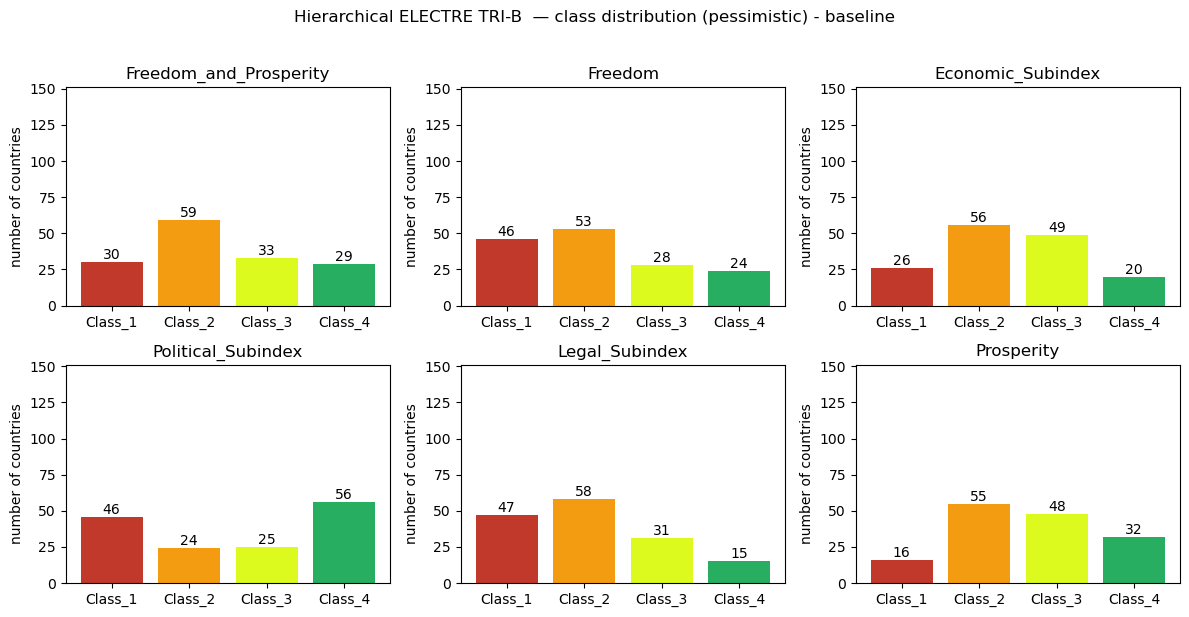

In [11]:
nodes = list(lambdas.keys())  # root + dimensions + subdimensions
colors = {"Class_1": "#c0392b", "Class_2": "#f39c12", "Class_3": "#ddfa1f", "Class_4": "#27ae60"}

ncols = 3
nrows = math.ceil(len(nodes) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for ax, node in zip(axes, nodes):
    class_counts = res_pess[node].value_counts().reindex(categories, fill_value=0)
    ax.bar(class_counts.index, class_counts.values, color=[colors[c] for c in class_counts.index])
    ax.set_title(node)
    ax.set_ylabel("number of countries")
    ax.set_ylim(0, len(df))
    for x, y in zip(class_counts.index, class_counts.values):
        ax.text(x, y, str(y), ha="center", va="bottom")

# turn off the leftover subplots
for ax in axes[len(nodes):]:
    ax.axis("off")

fig.suptitle("Hierarchical ELECTRE TRI-B  — class distribution (pessimistic) - baseline",
             y=1.02)
plt.tight_layout()
plt.show()

In [12]:
_ = country_hierarchy("Italy", Root, df, res_pess)

Country: Italy
Freedom_and_Prosperity                                  -> Class_3
  Freedom                                               -> Class_3
    Economic_Subindex                                   -> Class_3
      Proper_Rights                                        (value = 65.66)
      Trade_Freedom                                        (value = 91.65)
      Investm_Freedom                                      (value = 80.00)
      Womens_Economic_Freedom                              (value = 97.50)
    Political_Subindex                                  -> Class_4
      PF_Elections                                         (value = 97.70)
      Civil_Liberties                                      (value = 92.20)
      Political_Rights                                     (value = 87.00)
      Legislative_Constraints_on_the_Executive             (value = 95.10)
    Legal_Subindex                                      -> Class_3
      Clarity_of_the_Law                          

# SMAA-TRI

## Fixed weights

In [13]:
N_SIM = 10000        
SEED = 42            

categories = ["Class_1", "Class_2", "Class_3", "Class_4"]  # Class_4 is the best

rng = np.random.default_rng(SEED)
nodes = list(lambdas.keys())
alt_dicts = {name: df.loc[name].to_dict() for name in df.index}

counts = {c: {n: Counter() for n in nodes} for c in df.index}
params_fixed_w = []

for _ in range(N_SIM):
    q_s  = {lf: rng.uniform(3, 5)  for lf in leaves}
    p_s  = {lf: rng.uniform(5, 7)  for lf in leaves}
    v_s  = {lf: rng.uniform(30, 50) for lf in leaves}
    b1_s = {lf: rng.uniform(35, 45) for lf in leaves}
    b2_s = {lf: rng.uniform(55, 65) for lf in leaves}
    b3_s = {lf: rng.uniform(75, 85) for lf in leaves}
    model.q, model.p, model.v = q_s, p_s, v_s
    model.profiles = {"b1": b1_s, "b2": b2_s, "b3": b3_s}
    params_fixed_w.append({"q": q_s, "p": p_s, "v": v_s, "b1": b1_s, "b2": b2_s, "b3": b3_s})

    for name, alt in alt_dicts.items():
        assigned = model.assign_all_nodes(alt, procedure="pessimistic")
        for n in nodes:
            counts[name][n][assigned[n]] += 1

params_fixed_w_df = params_to_df(params_fixed_w)
print(f"Simulation finished: {N_SIM} iterations.")
print(f"Parameters stored in 'params_fixed_w' (list of dicts) and "
      f"'params_fixed_w_df' {params_fixed_w_df.shape}.")

params_fixed_w_df

Simulation finished: 10000 iterations.
Parameters stored in 'params_fixed_w' (list of dicts) and 'params_fixed_w_df' (10000, 114).


param                 q                                                        \
id        Proper_Rights Trade_Freedom Investm_Freedom Womens_Economic_Freedom   
iteration                                                                       
0              4.547912      3.877757        4.717196                4.394736   
1              3.353546      4.713229        4.517039                4.438926   
2              4.267950      3.211795        3.280679                3.838229   
3              4.601768      4.187364        4.565248                4.590230   
4              4.960054      3.917121        4.568162                4.272817   
...                 ...           ...             ...                     ...   
9995           4.312794      4.801489        3.601573                4.297673   
9996           3.644762      3.028417        3.154162                4.075380   
9997           4.437972      4.499929        4.208617                4.227554   
9998           4.017967      4.560075        3.042194                4.519499   
9999           3.830390      3.337811        4.814988                3.524143   

param                                                    \
id        PF_Elections Civil_Liberties Political_Rights   
iteration                                                 
0             3.188355        4.951245         4.522279   
1             3.864186        4.254618         4.168196   
2             4.932464        4.192085         4.866046   
3             4.892054        3.506767         4.180152   
4             4.144826        3.290261         4.892049   
...                ...             ...              ...   
9995          3.718654        3.143052         3.609432   
9996          4.020170        4.067913         4.083134   
9997          4.068745        3.801431         4.775040   
9998          3.211137        4.286499         4.200479   
9999          3.574195        4.003742         3.498541   

param                                                                  \
id        Legislative_Constraints_on_the_Executive Clarity_of_the_Law   
iteration                                                               
0                                         4.572129           3.256227   
1                                         4.299693           3.168889   
2                                         4.608722           3.934763   
3                                         3.190098           4.232331   
4                                         3.602685           4.156034   
...                                            ...                ...   
9995                                      3.924120           3.233445   
9996                                      3.364774           4.772518   
9997                                      3.279267           3.155937   
9998                                      4.327158           3.330052   
9999                                      4.405726           4.715272   

param                                              ...  \
id        Judicial_Independence_and_Effectiveness  ...   
iteration                                          ...   
0                                        3.900772  ...   
1                                        3.831615  ...   
2                                        4.569527  ...   
3                                        3.342583  ...   
4                                        4.399552  ...   
...                                           ...  ...   
9995                                     3.235124  ...   
9996                                     4.950569  ...   
9997                                     4.550990  ...   
9998                                     4.664313  ...   
9999                                     3.223952  ...   

param                                          b3                             \
id        Judicial_Independence_and_Effectiveness Bureaucracy_and_Corruption   
iteration                                 

In [14]:
accept = {}
for name in df.index:
    row = {}
    for n in nodes:
        total = sum(counts[name][n].values())  
        for c in categories:
            row[(n, c)] = counts[name][n][c] / total
    accept[name] = row

acceptability = pd.DataFrame(accept).T
acceptability.columns = pd.MultiIndex.from_tuples(acceptability.columns, names=["node", "class"])
acceptability = acceptability[[(n, c) for n in nodes for c in categories]]

In [15]:
acceptability

node                 Freedom_and_Prosperity                         Freedom  \
class                               Class_1 Class_2 Class_3 Class_4 Class_1   
Angola                               0.1576  0.8424     0.0     0.0  0.9777   
Albania                              0.0000  0.0000     1.0     0.0  0.0000   
United Arab Emirates                 0.4336  0.5664     0.0     0.0  1.0000   
Argentina                            0.0000  0.0000     1.0     0.0  0.0000   
Armenia                              0.0000  0.0000     1.0     0.0  0.0000   
...                                     ...     ...     ...     ...     ...   
Vietnam                              0.1990  0.8010     0.0     0.0  0.9905   
Yemen                                1.0000  0.0000     0.0     0.0  1.0000   
South Africa                         0.2734  0.7266     0.0     0.0  0.0000   
Zambia                               0.0000  1.0000     0.0     0.0  0.0000   
Zimbabwe                             0.5572  0.4428     0.0     0.0  1.0000   

node                                         Economic_Subindex          ...  \
class                Class_2 Class_3 Class_4           Class_1 Class_2  ...   
Angola                0.0223  0.0000     0.0             0.959  0.0410  ...   
Albania               0.1033  0.8967     0.0             0.000  0.9856  ...   
United Arab Emirates  0.0000  0.0000     0.0             0.000  0.4719  ...   
Argentina             0.9148  0.0852     0.0             0.000  1.0000  ...   
Armenia               0.7074  0.2926     0.0             0.000  0.0508  ...   
...                      ...     ...     ...               ...     ...  ...   
Vietnam               0.0095  0.0000     0.0             0.000  0.5367  ...   
Yemen                 0.0000  0.0000     0.0             1.000  0.0000  ...   
South Africa          0.9668  0.0332     0.0             0.000  1.0000  ...   
Zambia                0.9838  0.0162     0.0             0.000  0.9994  ...   
Zimbabwe              0.0000  0.0000     0.0             1.000  0.0000  ...   

node                 Political_Subindex         Legal_Subindex          \
class                           Class_3 Class_4        Class_1 Class_2   
Angola                           0.0000  0.0000         0.2804  0.7196   
Albania                          0.8309  0.1691         0.0000  0.7878   
United Arab Emirates             0.0000  0.0000         0.0000  1.0000   
Argentina                        0.0000  1.0000         0.0000  1.0000   
Armenia                          1.0000  0.0000         0.0000  1.0000   
...                                 ...     ...            ...     ...   
Vietnam                          0.0000  0.0000         0.3679  0.6321   
Yemen                            0.0000  0.0000         1.0000  0.0000   
South Africa                     0.0000  1.0000         0.0000  0.9997   
Zambia                           0.0922  0.9078         0.0053  0.9947   
Zimbabwe                         0.0000  0.0000         1.0000  0.0000   

node                                 Prosperity                          
class                Class_3 Class_4    Class_1 Class_2 Class_3 Class_4  
Angola                0.0000     0.0     0.0000  1.0000  0.0000  0.0000  
Albania               0.2122     0.0     0.0000  0.0000  1.0000  0.0000  
United Arab Emirates  0.0000     0.0     0.0000  0.0000  0.9673  0.0327  
Argentina             0.0000     0.0     0.0000  0.0000  0.9719  0.0281  
Armenia               0.0000     0.0     0.0000  0.0000  1.0000  0.0000  
...                      ...     ...        ...     ...     ...     ...  
Vietnam               0.0000     0.0     0.0000  0.0015  0.9985  0.0000  
Yemen                 0.0000     0.0     1.0000  0.0000  0.0000  0.0000  
South Africa          0.0003     0.0     1.0000  0.0000  0.0000  0.0000  
Zambia                0.0000     0.0     0.1625  0.8375  0.0000  0.0000  
Zimbabwe              0.0000     0.0     0.0096  0.9904  0.0000  0.0000  

[151 rows x 24 col

In [16]:
class_acceptability_smaa(acceptability, categories, "Freedom_and_Prosperity").round(3)

class,Class_1,Class_2,Class_3,Class_4
Australia,0.0,0.0,0.0,1.0
Belgium,0.0,0.0,0.0,1.0
Switzerland,0.0,0.0,0.0,1.0
Czech Republic,0.0,0.0,0.0,1.0
Germany,0.0,0.0,0.0,1.0
...,...,...,...,...
Syria,1.0,0.0,0.0,0.0
Chad,1.0,0.0,0.0,0.0
Tajikistan,1.0,0.0,0.0,0.0
Venezuela,1.0,0.0,0.0,0.0


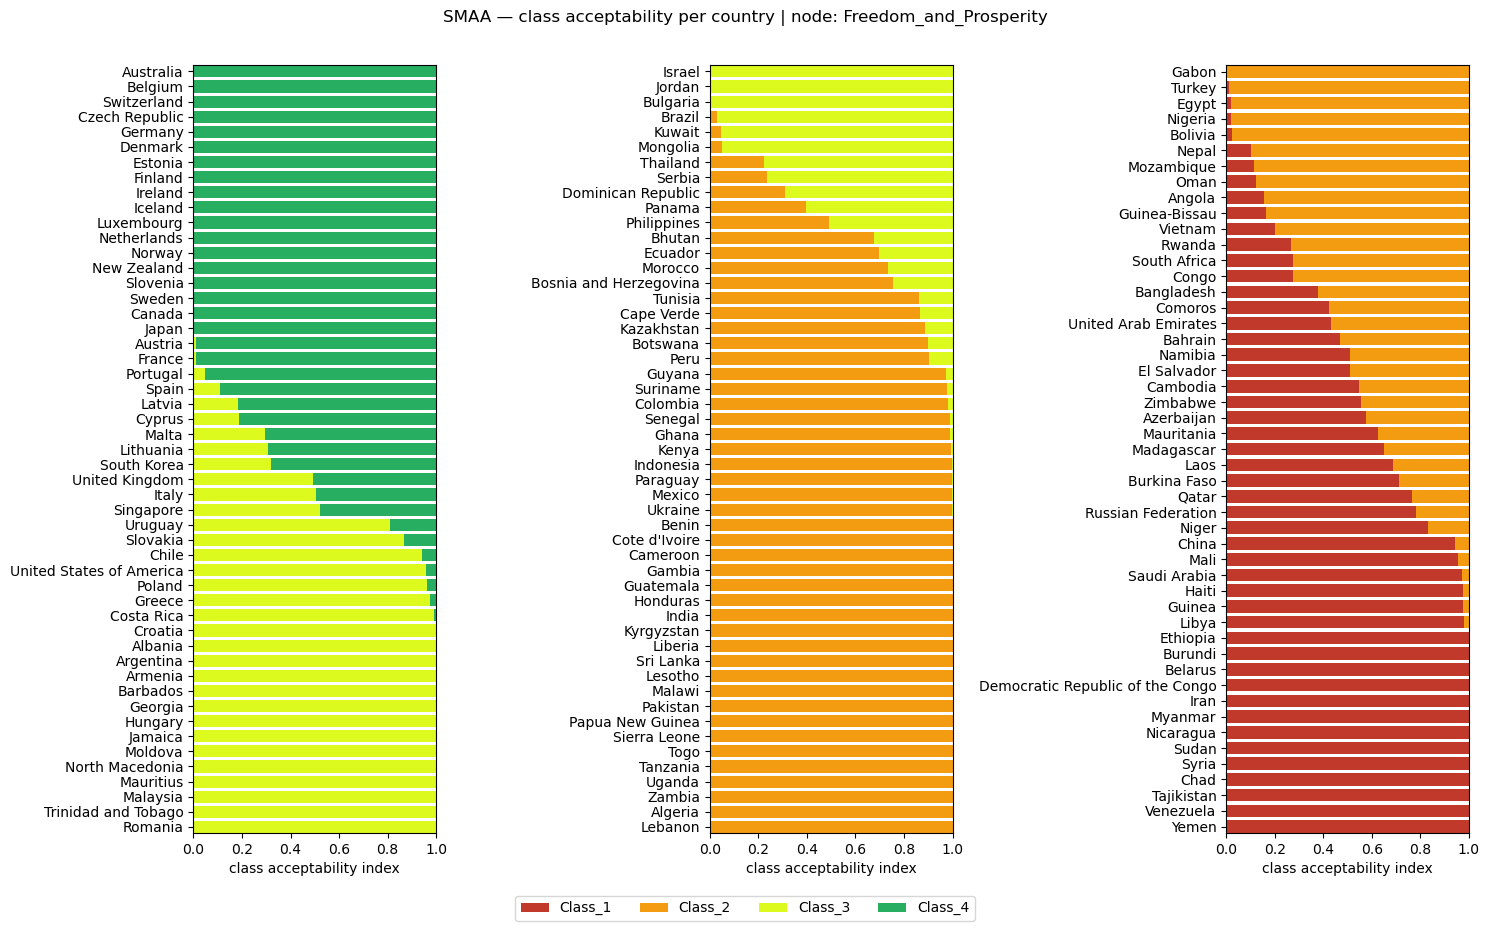

In [18]:
colors = {"Class_1": "#c0392b", "Class_2": "#f39c12", "Class_3": "#ddfa1f", "Class_4": "#27ae60"}

plot_acceptability_smaa(acceptability, categories, colors, "Freedom_and_Prosperity")

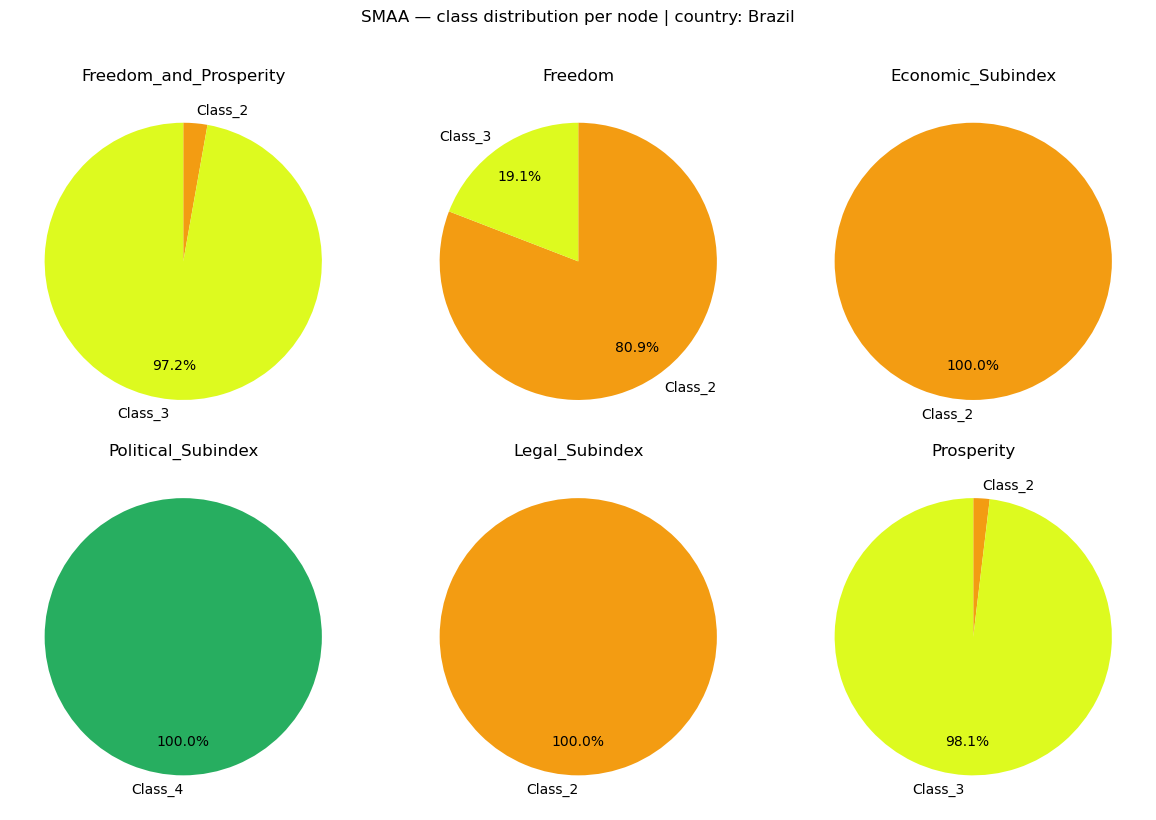

In [19]:
plot_country_pies_smaa(acceptability, nodes, categories, colors, "Brazil" )

# SMAA-TRI

## Varying weights

In [20]:
# Varying-weights version
N_SIM = 10000          
SEED = 42             
rng = np.random.default_rng(SEED)
nodes = list(lambdas.keys())
alt_dicts = {name: df.loc[name].to_dict() for name in df.index}
def sample_weights(node, weight, rng, out=None):
    """Split `weight` among the children with Dirichlet(1,...,1) and recurse down to the leaves. 
    Preserves the hierarchy: on average it keeps each dimension's expected weight (Freedom≈0.5, etc.)."""
    if out is None:
        out = {}
    if node.is_leaf():
        out[node.leaf_id] = weight
        return out
    fracs = rng.dirichlet(np.ones(len(node.children)))
    for child, f in zip(node.children, fracs):
        sample_weights(child, weight * f, rng, out)
    return out

# counts_w[country][node] -> Counter({class: number of times})
counts_w = {c: {n: Counter() for n in nodes} for c in df.index}
params_varying_w = []

for _ in range(N_SIM):
    w   = sample_weights(Root, 1.0, rng)
    lam = compute_lambdas(Root, w, lambda_frac)
    q_s  = {lf: rng.uniform(3, 5)  for lf in leaves}
    p_s  = {lf: rng.uniform(5, 7)  for lf in leaves}
    v_s  = {lf: rng.uniform(30, 50) for lf in leaves}
    b1_s = {lf: rng.uniform(35, 45) for lf in leaves}
    b2_s = {lf: rng.uniform(55, 65) for lf in leaves}
    b3_s = {lf: rng.uniform(75, 85) for lf in leaves}
    model.q, model.p, model.v = q_s, p_s, v_s
    model.weights, model.lambdas = w, lam
    model.profiles = {"b1": b1_s, "b2": b2_s, "b3": b3_s}

    params_varying_w.append(
        {"weights": w, "lambdas": lam,
         "q": q_s, "p": p_s, "v": v_s, "b1": b1_s, "b2": b2_s, "b3": b3_s}
    )

    for name, alt in alt_dicts.items():
        assigned = model.assign_all_nodes(alt, procedure="pessimistic")
        for n in nodes:
            counts_w[name][n][assigned[n]] += 1

# restore the base-scenario parameters in the model
model.weights, model.lambdas = weights, lambdas
model.q, model.p, model.v, model.profiles = q, p, v, profiles

params_varying_w_df = params_to_df(params_varying_w)
print(f"Simulation finished: {N_SIM} iterations.")
params_varying_w_df

Simulation finished: 10000 iterations.


param           weights                                                        \
id        Proper_Rights Trade_Freedom Investm_Freedom Womens_Economic_Freedom   
iteration                                                                       
0              0.105283      0.102189        0.226437                0.005747   
1              0.053300      0.089674        0.060781                0.086729   
2              0.069828      0.320778        0.082074                0.210903   
3              0.019316      0.010827        0.000394                0.000044   
4              0.001048      0.006473        0.004561                0.000668   
...                 ...           ...             ...                     ...   
9995           0.000084      0.001191        0.006337                0.003355   
9996           0.002359      0.000731        0.000026                0.000648   
9997           0.000363      0.000045        0.000136                0.000210   
9998           0.021112      0.082359        0.080484                0.020836   
9999           0.141162      0.003578        0.070248                0.050808   

param                                                    \
id        PF_Elections Civil_Liberties Political_Rights   
iteration                                                 
0             0.013711        0.000923         0.014267   
1             0.014776        0.019177         0.000899   
2             0.034898        0.001948         0.016849   
3             0.002521        0.014475         0.091618   
4             0.014758        0.082914         0.019731   
...                ...             ...              ...   
9995          0.002298        0.003574         0.000517   
9996          0.000942        0.002246         0.002967   
9997          0.062581        0.024319         0.296419   
9998          0.388504        0.274480         0.008183   
9999          0.010090        0.000494         0.014315   

param                                                                  \
id        Legislative_Constraints_on_the_Executive Clarity_of_the_Law   
iteration                                                               
0                                         0.022682           0.002829   
1                                         0.049665           0.126588   
2                                         0.073703           0.000325   
3                                         0.005275           0.002179   
4                                         0.035162           0.154382   
...                                            ...                ...   
9995                                      0.002694           0.016953   
9996                                      0.000400           0.000109   
9997                                      0.072964           0.013622   
9998                                      0.039605           0.003308   
9999                                      0.011081           0.026091   

param                                              ...  \
id        Judicial_Independence_and_Effectiveness  ...   
iteration                                          ...   
0                                        0.009007  ...   
1                                        0.029304  ...   
2                                        0.004232  ...   
3                                        0.000131  ...   
4                                        0.037000  ...   
...                                           ...  ...   
9995                                     0.018849  ...   
9996                                     0.000861  ...   
9997                                     0.016957  ...   
9998                                     0.000392  ...   
9999                                     0.028212  ...   

param                                          b3                             \
id        Judicial_Independence_and_Effectiveness Bureaucracy_and_Corruption   
iteration                                 

In [22]:
accept_w = {}
for name in df.index:
    row = {}
    for n in nodes:
        total = sum(counts_w[name][n].values())  
        for c in categories:
            row[(n, c)] = counts_w[name][n][c] / total
    accept_w[name] = row

acceptability_w = pd.DataFrame(accept_w).T
acceptability_w.columns = pd.MultiIndex.from_tuples(acceptability_w.columns, names=["node", "class"])
acceptability_w = acceptability_w[[(n, c) for n in nodes for c in categories]]

acceptability_w

node                 Freedom_and_Prosperity                         Freedom  \
class                               Class_1 Class_2 Class_3 Class_4 Class_1   
Angola                               0.3161  0.6838  0.0001  0.0000  0.8451   
Albania                              0.0000  0.0645  0.9341  0.0014  0.0000   
United Arab Emirates                 0.4653  0.5347  0.0000  0.0000  0.9408   
Argentina                            0.0003  0.1648  0.8327  0.0022  0.0021   
Armenia                              0.0000  0.1739  0.8246  0.0015  0.0000   
...                                     ...     ...     ...     ...     ...   
Vietnam                              0.2402  0.7592  0.0006  0.0000  0.8461   
Yemen                                0.9883  0.0117  0.0000  0.0000  1.0000   
South Africa                         0.3150  0.6850  0.0000  0.0000  0.0005   
Zambia                               0.1091  0.8548  0.0361  0.0000  0.0196   
Zimbabwe                             0.4742  0.5258  0.0000  0.0000  0.9337   

node                                         Economic_Subindex          ...  \
class                Class_2 Class_3 Class_4           Class_1 Class_2  ...   
Angola                0.1549  0.0000  0.0000            0.8961  0.1039  ...   
Albania               0.4338  0.5653  0.0009            0.0000  0.7693  ...   
United Arab Emirates  0.0592  0.0000  0.0000            0.0000  0.5076  ...   
Argentina             0.7379  0.2598  0.0002            0.0000  0.9686  ...   
Armenia               0.6088  0.3907  0.0005            0.0000  0.2344  ...   
...                      ...     ...     ...               ...     ...  ...   
Vietnam               0.1539  0.0000  0.0000            0.0000  0.5397  ...   
Yemen                 0.0000  0.0000  0.0000            0.9552  0.0448  ...   
South Africa          0.7612  0.2370  0.0013            0.0045  0.9699  ...   
Zambia                0.7948  0.1856  0.0000            0.0000  0.8848  ...   
Zimbabwe              0.0663  0.0000  0.0000            0.9988  0.0012  ...   

node                 Political_Subindex         Legal_Subindex          \
class                           Class_3 Class_4        Class_1 Class_2   
Angola                           0.0000  0.0000         0.4142  0.5858   
Albania                          0.7316  0.2684         0.0000  0.7024   
United Arab Emirates             0.0000  0.0000         0.0075  0.8656   
Argentina                        0.0000  1.0000         0.0187  0.9248   
Armenia                          0.8656  0.1343         0.0000  0.9933   
...                                 ...     ...            ...     ...   
Vietnam                          0.0000  0.0000         0.4291  0.5705   
Yemen                            0.0000  0.0000         1.0000  0.0000   
South Africa                     0.0000  1.0000         0.0000  0.9445   
Zambia                           0.2269  0.7731         0.1589  0.8340   
Zimbabwe                         0.0033  0.0000         0.9968  0.0032   

node                                 Prosperity                          
class                Class_3 Class_4    Class_1 Class_2 Class_3 Class_4  
Angola                0.0000     0.0     0.0776  0.9155  0.0069  0.0000  
Albania               0.2976     0.0     0.0000  0.0065  0.9909  0.0026  
United Arab Emirates  0.1269     0.0     0.0000  0.2044  0.6067  0.1889  
Argentina             0.0565     0.0     0.0000  0.0000  0.8923  0.1077  
Armenia               0.0067     0.0     0.0000  0.0000  0.9865  0.0135  
...                      ...     ...        ...     ...     ...     ...  
Vietnam               0.0004     0.0     0.0000  0.0939  0.9055  0.0006  
Yemen                 0.0000     0.0     0.9270  0.0729  0.0001  0.0000  
South Africa          0.0555     0.0     0.8825  0.1175  0.0000  0.0000  
Zambia                0.0071     0.0     0.4268  0.5731  0.0001  0.0000  
Zimbabwe              0.0000     0.0     0.0595  0.9365  0.0040  0.0000  

[151 rows x 24 col

In [39]:
class_acceptability_smaa(acceptability, categories, "Freedom_and_Prosperity").round(5).loc['Sweden']

class
Class_1    0.0
Class_2    0.0
Class_3    0.0
Class_4    1.0
Name: Sweden, dtype: float64

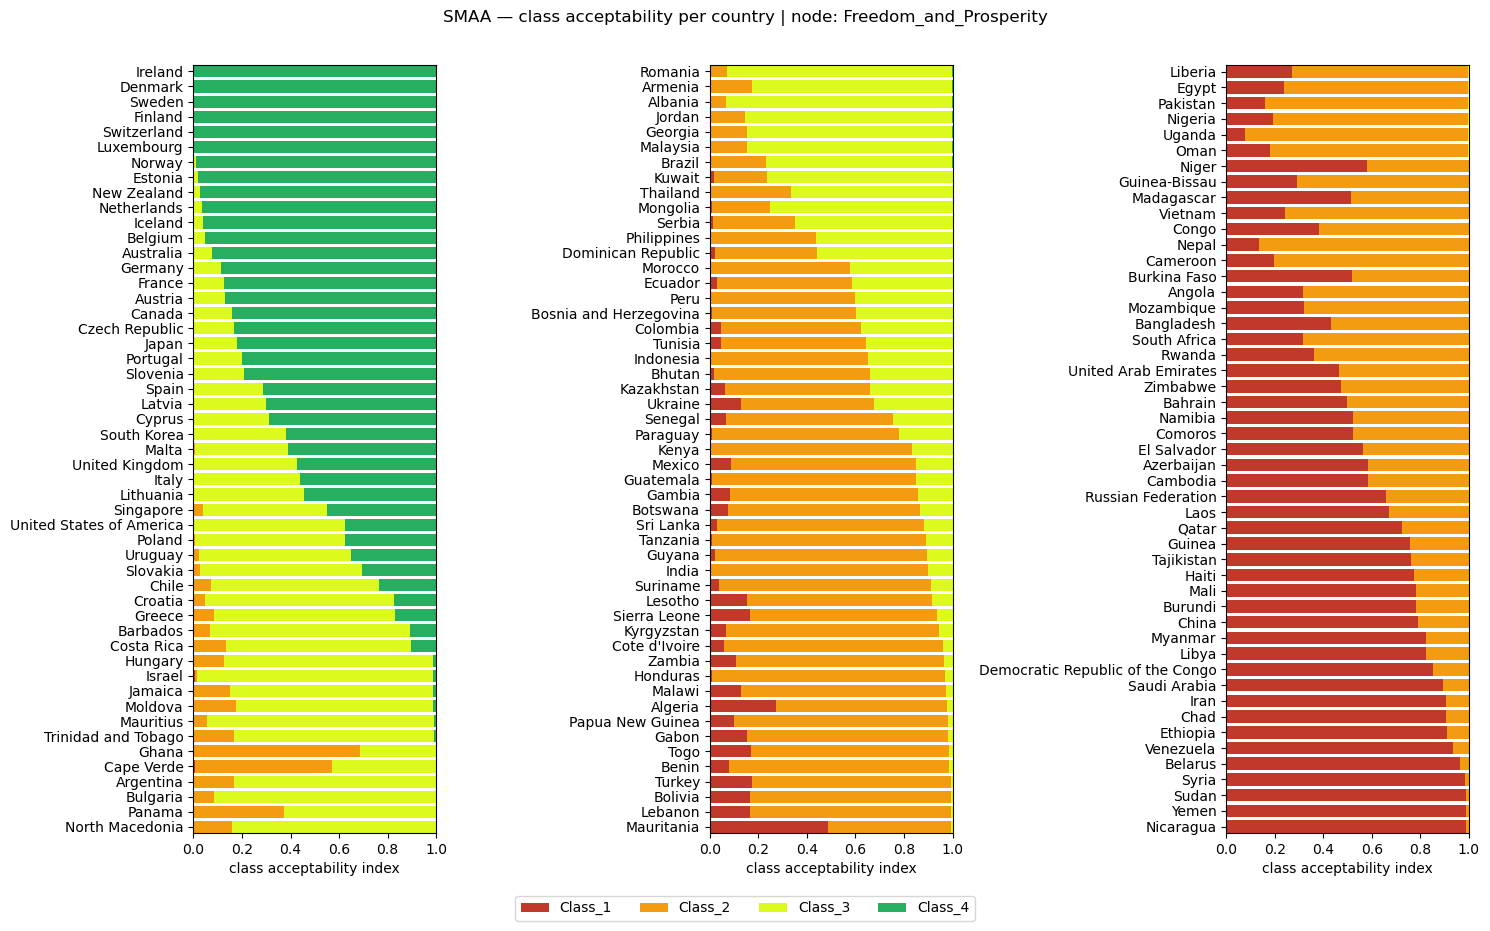

In [ ]:
colors = {"Class_1": "#c0392b", "Class_2": "#f39c12", "Class_3": "#ddfa1f", "Class_4": "#27ae60"}

plot_acceptability_smaa(acceptability_w, categories, colors, "Freedom_and_Prosperity")

In [41]:
acceptability_w.loc["Mauritania", "Freedom_and_Prosperity"].reindex(categories)

class
Class_1    0.4850
Class_2    0.5091
Class_3    0.0059
Class_4    0.0000
Name: Mauritania, dtype: float64

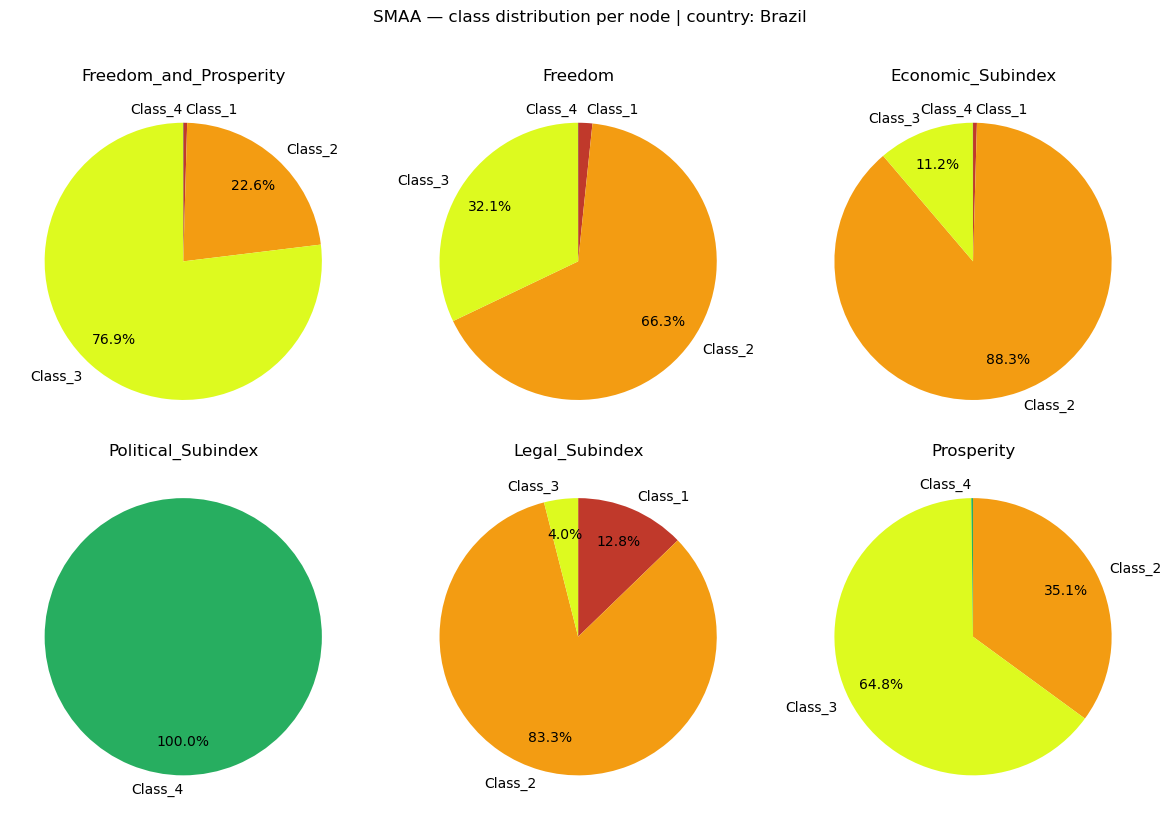

In [27]:
plot_country_pies_smaa(acceptability_w, nodes, categories, colors, "Brazil" )

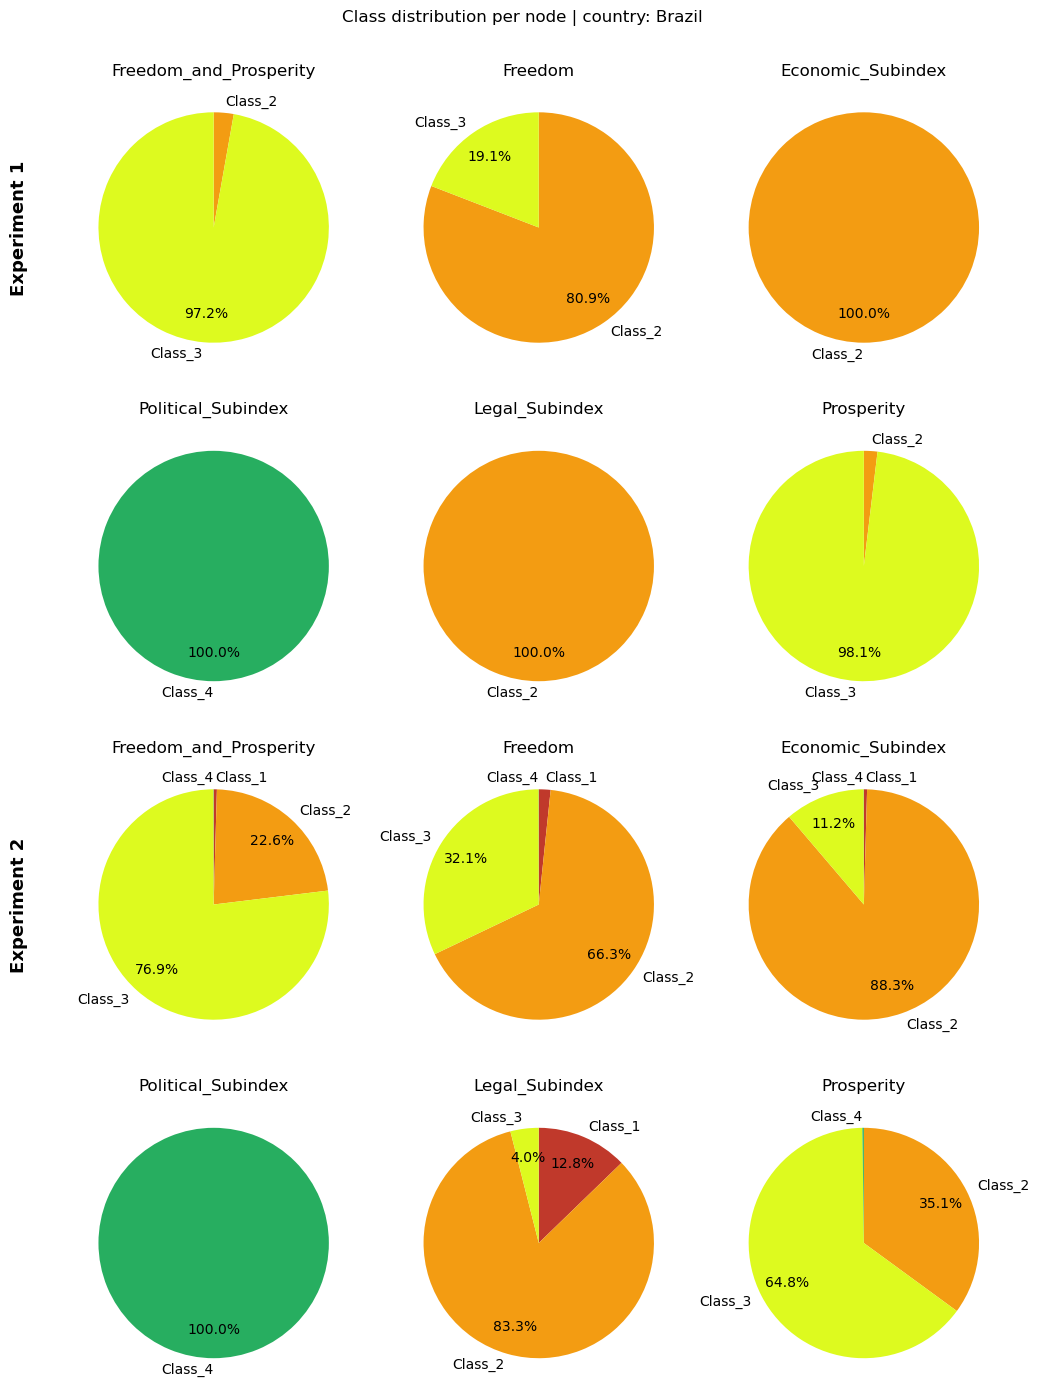

In [29]:
def plot_country_pies_smaa_rows(experiments, nodes, categories, colors, country,
                                ncols=3, min_pct=3.0, panel_w=3.5, panel_h=3.5):
    """Single figure for one country, stacking the experiments vertically.

    Each experiment occupies its own block of rows (ncols pies per row), so
    with 6 nodes and ncols=3 every experiment takes 2 rows -> 4 rows in total.

    Parameters
    ----------
    experiments : list of (label, acceptability) tuples, stacked top to bottom.
    country     : country name to plot.

    Slices smaller than `min_pct` percent keep their wedge but hide the
    percentage text, so labels of tiny slivers don't overlap each other.
    """
    for _, acc in experiments:
        if country not in acc.index:
            raise KeyError(f"Country '{country}' not found. "
                           f"e.g.: {list(acc.index[:5])} ...")

    rows_per_exp = math.ceil(len(nodes) / ncols)
    nrows = rows_per_exp * len(experiments)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(panel_w * ncols, panel_h * nrows),
                             squeeze=False)

    for e, (label, acc) in enumerate(experiments):
        block = axes[e * rows_per_exp:(e + 1) * rows_per_exp].flatten()
        for ax, n in zip(block, nodes):
            probs = acc.loc[country, n].reindex(categories)
            present = probs[probs > 0]  # drop classes with 0%
            ax.pie(present.values,
                   labels=present.index,
                   colors=[colors[cl] for cl in present.index],
                   autopct=lambda pct: f"{pct:.1f}%" if pct >= min_pct else "",
                   pctdistance=0.75,
                   startangle=90,
                   counterclock=False)
            ax.set_title(n)
        for ax in block[len(nodes):]:
            ax.axis("off")
        # experiment label on the left of its first row
        block[0].set_ylabel(label, fontweight="bold", fontsize=13, labelpad=30)

    fig.suptitle(f"Class distribution per node | country: {country}", y=1.0)
    plt.tight_layout()
    plt.show()
    return


plot_country_pies_smaa_rows(
    experiments=[("Experiment 1", acceptability), ("Experiment 2", acceptability_w)],
    nodes=nodes,
    categories=categories,
    colors=colors,
    country="Brazil",
)


In [30]:
# Classification table per country:
#   col 1 (baseline)            -> original classification, all parameters fixed (res_pess)
#   col 2 (exp1_equal_weights)  -> most frequent class, experiment 1 (fixed/equal weights SMAA)
#   col 3 (exp2_varying_weights)-> most frequent class, experiment 2 (varying weights SMAA)
node = "Freedom_and_Prosperity"

baseline_class      = res_pess[node]
exp1_mode_class     = acceptability[node].reindex(columns=categories).idxmax(axis=1)    # equal weights
exp2_mode_class     = acceptability_w[node].reindex(columns=categories).idxmax(axis=1)  # varying weights

country_class_df = pd.DataFrame({
    "baseline":             baseline_class,
    "exp1_equal_weights":   exp1_mode_class,
    "exp2_varying_weights": exp2_mode_class,
})
country_class_df

,baseline,exp1_equal_weights,exp2_varying_weights
Angola,Class_2,Class_2,Class_2
Albania,Class_3,Class_3,Class_3
United Arab Emirates,Class_2,Class_2,Class_2
Argentina,Class_3,Class_3,Class_3
Armenia,Class_3,Class_3,Class_3
...,...,...,...
Vietnam,Class_2,Class_2,Class_2
Yemen,Class_1,Class_1,Class_1
South Africa,Class_2,Class_2,Class_2
Zambia,Class_2,Class_2,Class_2


In [31]:
# Countries whose most frequent class in experiment 1 (equal weights)
# differs from the baseline classification (col 1 vs col 2)
diff_baseline_exp1 = country_class_df[country_class_df.iloc[:, 0] != country_class_df.iloc[:, 1]]
diff_baseline_exp1

,baseline,exp1_equal_weights,exp2_varying_weights
Ecuador,Class_3,Class_2,Class_2
Philippines,Class_2,Class_3,Class_3
Singapore,Class_4,Class_3,Class_3
Zimbabwe,Class_2,Class_1,Class_2


In [32]:
# Countries whose most frequent class in experiment 2 (varying weights)
# differs from the baseline classification (col 1 vs col 3)
diff_baseline_exp2 = country_class_df[country_class_df.iloc[:, 0] != country_class_df.iloc[:, 2]]
diff_baseline_exp2

,baseline,exp1_equal_weights,exp2_varying_weights
Comoros,Class_2,Class_2,Class_1
Ecuador,Class_3,Class_2,Class_2
Italy,Class_3,Class_3,Class_4
Mauritania,Class_1,Class_1,Class_2
Philippines,Class_2,Class_3,Class_3
Singapore,Class_4,Class_3,Class_3


# SMAA-TRI

## Fixed Freedom/Prosperity split (0.5 / 0.5), varying children weights

In [ ]:
# Fixed Freedom/Prosperity split (0.5 / 0.5), children weights vary
N_SIM = 10000          
SEED = 42             
rng = np.random.default_rng(SEED)
nodes = list(lambdas.keys())
alt_dicts = {name: df.loc[name].to_dict() for name in df.index}

# counts_fp[country][node] -> Counter({class: number of times})
counts_fp = {c: {n: Counter() for n in nodes} for c in df.index}
params_fixed_fp = []

for _ in range(N_SIM):
    # pin the top-level split: Freedom = 0.5, Prosperity = 0.5,
    # vary everything below via Dirichlet (full cascade)
    w = {}
    sample_weights(Freedom,    0.5, rng, w)
    sample_weights(Prosperity, 0.5, rng, w)
    lam = compute_lambdas(Root, w, lambda_frac)
    q_s  = {lf: rng.uniform(3, 5)  for lf in leaves}
    p_s  = {lf: rng.uniform(5, 7)  for lf in leaves}
    v_s  = {lf: rng.uniform(30, 50) for lf in leaves}
    b1_s = {lf: rng.uniform(35, 45) for lf in leaves}
    b2_s = {lf: rng.uniform(55, 65) for lf in leaves}
    b3_s = {lf: rng.uniform(75, 85) for lf in leaves}
    model.q, model.p, model.v = q_s, p_s, v_s
    model.weights, model.lambdas = w, lam
    model.profiles = {"b1": b1_s, "b2": b2_s, "b3": b3_s}

    params_fixed_fp.append(
        {"weights": w, "lambdas": lam,
         "q": q_s, "p": p_s, "v": v_s, "b1": b1_s, "b2": b2_s, "b3": b3_s}
    )

    for name, alt in alt_dicts.items():
        assigned = model.assign_all_nodes(alt, procedure="pessimistic")
        for n in nodes:
            counts_fp[name][n][assigned[n]] += 1

# restore the base-scenario parameters in the model
model.weights, model.lambdas = weights, lambdas
model.q, model.p, model.v, model.profiles = q, p, v, profiles

params_fixed_fp_df = params_to_df(params_fixed_fp)
print(f"Simulation finished: {N_SIM} iterations.")
params_fixed_fp_df

Simulation finished: 1000 iterations.


param           weights                                                        \
id        Proper_Rights Trade_Freedom Investm_Freedom Womens_Economic_Freedom   
iteration                                                                       
0              0.014620      0.004516        0.075904                0.073673   
1              0.028203      0.113856        0.033126                0.186779   
2              0.007475      0.009377        0.001940                0.031653   
3              0.002413      0.000149        0.000807                0.001472   
4              0.051129      0.067736        0.009987                0.043136   
...                 ...           ...             ...                     ...   
995            0.003125      0.012535        0.062815                0.015211   
996            0.010168      0.002355        0.012305                0.028393   
997            0.019184      0.005473        0.044531                0.000785   
998            0.037119      0.029797        0.054683                0.147595   
999            0.000089      0.000024        0.000025                0.000117   

param                                                    \
id        PF_Elections Civil_Liberties Political_Rights   
iteration                                                 
0             0.118548        0.003009         0.039710   
1             0.008237        0.013857         0.009393   
2             0.164257        0.022649         0.032465   
3             0.125893        0.012490         0.224893   
4             0.033418        0.001161         0.013891   
...                ...             ...              ...   
995           0.076604        0.026799         0.061891   
996           0.038686        0.157978         0.078648   
997           0.043386        0.016000         0.008649   
998           0.000133        0.000296         0.000021   
999           0.050036        0.234274         0.044945   

param                                                                  \
id        Legislative_Constraints_on_the_Executive Clarity_of_the_Law   
iteration                                                               
0                                         0.002673           0.039682   
1                                         0.013402           0.008442   
2                                         0.149140           0.006444   
3                                         0.126060           0.000062   
4                                         0.023156           0.018092   
...                                            ...                ...   
995                                       0.103294           0.004634   
996                                       0.021475           0.026510   
997                                       0.025269           0.040490   
998                                       0.000039           0.098924   
999                                       0.108219           0.025763   

param                                              ...  \
id        Judicial_Independence_and_Effectiveness  ...   
iteration                                          ...   
0                                        0.063087  ...   
1                                        0.010957  ...   
2                                        0.016560  ...   
3                                        0.000007  ...   
4                                        0.111753  ...   
...                                           ...  ...   
995                                      0.033509  ...   
996                                      0.070872  ...   
997                                      0.091533  ...   
998                                      0.075324  ...   
999                                      0.005315  ...   

param                                          b3                             \
id        Judicial_Independence_and_Effectiveness Bureaucracy_and_Corruption   
iteration                                 

In [161]:
accept_fp = {}
for name in df.index:
    row = {}
    for n in nodes:
        total = sum(counts_fp[name][n].values())  
        for c in categories:
            row[(n, c)] = counts_fp[name][n][c] / total
    accept_fp[name] = row

acceptability_fp = pd.DataFrame(accept_fp).T
acceptability_fp.columns = pd.MultiIndex.from_tuples(acceptability_fp.columns, names=["node", "class"])
acceptability_fp = acceptability_fp[[(n, c) for n in nodes for c in categories]]

acceptability_fp

node                 Freedom_and_Prosperity                         Freedom  \
class                               Class_1 Class_2 Class_3 Class_4 Class_1   
Angola                                0.274   0.726   0.000   0.000   0.862   
Albania                               0.000   0.034   0.966   0.000   0.000   
United Arab Emirates                  0.456   0.544   0.000   0.000   0.998   
Argentina                             0.000   0.106   0.893   0.001   0.006   
Armenia                               0.000   0.119   0.881   0.000   0.000   
...                                     ...     ...     ...     ...     ...   
Vietnam                               0.199   0.801   0.000   0.000   0.958   
Yemen                                 0.997   0.003   0.000   0.000   1.000   
South Africa                          0.302   0.698   0.000   0.000   0.000   
Zambia                                0.073   0.925   0.002   0.000   0.019   
Zimbabwe                              0.571   0.429   0.000   0.000   0.934   

node                                         Economic_Subindex          ...  \
class                Class_2 Class_3 Class_4           Class_1 Class_2  ...   
Angola                 0.138   0.000     0.0             0.872   0.128  ...   
Albania                0.275   0.725     0.0             0.000   0.751  ...   
United Arab Emirates   0.002   0.000     0.0             0.000   0.495  ...   
Argentina              0.704   0.290     0.0             0.000   0.969  ...   
Armenia                0.505   0.495     0.0             0.000   0.248  ...   
...                      ...     ...     ...               ...     ...  ...   
Vietnam                0.042   0.000     0.0             0.000   0.533  ...   
Yemen                  0.000   0.000     0.0             0.948   0.052  ...   
South Africa           0.769   0.231     0.0             0.005   0.988  ...   
Zambia                 0.873   0.108     0.0             0.000   0.891  ...   
Zimbabwe               0.066   0.000     0.0             0.999   0.001  ...   

node                 Political_Subindex         Legal_Subindex          \
class                           Class_3 Class_4        Class_1 Class_2   
Angola                            0.000   0.000          0.407   0.593   
Albania                           0.729   0.271          0.000   0.695   
United Arab Emirates              0.000   0.000          0.006   0.881   
Argentina                         0.000   1.000          0.022   0.936   
Armenia                           0.868   0.132          0.000   0.991   
...                                 ...     ...            ...     ...   
Vietnam                           0.000   0.000          0.395   0.605   
Yemen                             0.000   0.000          1.000   0.000   
South Africa                      0.000   1.000          0.000   0.949   
Zambia                            0.239   0.761          0.162   0.837   
Zimbabwe                          0.001   0.000          0.999   0.001   

node                                 Prosperity                          
class                Class_3 Class_4    Class_1 Class_2 Class_3 Class_4  
Angola                 0.000     0.0      0.072   0.923   0.005   0.000  
Albania                0.305     0.0      0.000   0.010   0.988   0.002  
United Arab Emirates   0.113     0.0      0.000   0.186   0.713   0.101  
Argentina              0.042     0.0      0.000   0.000   0.876   0.124  
Armenia                0.009     0.0      0.000   0.000   0.992   0.008  
...                      ...     ...        ...     ...     ...     ...  
Vietnam                0.000     0.0      0.000   0.089   0.911   0.000  
Yemen                  0.000     0.0      0.954   0.046   0.000   0.000  
South Africa           0.051     0.0      0.973   0.027   0.000   0.000  
Zambia                 0.001     0.0      0.303   0.697   0.000   0.000  
Zimbabwe               0.000     0.0      0.053   0.946   0.001   0.000  

[151 rows x 24 col

In [162]:
class_acceptability_smaa(acceptability_fp, categories, "Freedom_and_Prosperity").round(3)

class,Class_1,Class_2,Class_3,Class_4
Switzerland,0.000,0.000,0.0,1.0
Denmark,0.000,0.000,0.0,1.0
Finland,0.000,0.000,0.0,1.0
Ireland,0.000,0.000,0.0,1.0
Sweden,0.000,0.000,0.0,1.0
...,...,...,...,...
Belarus,0.995,0.005,0.0,0.0
Nicaragua,0.996,0.004,0.0,0.0
Yemen,0.997,0.003,0.0,0.0
Sudan,0.999,0.001,0.0,0.0


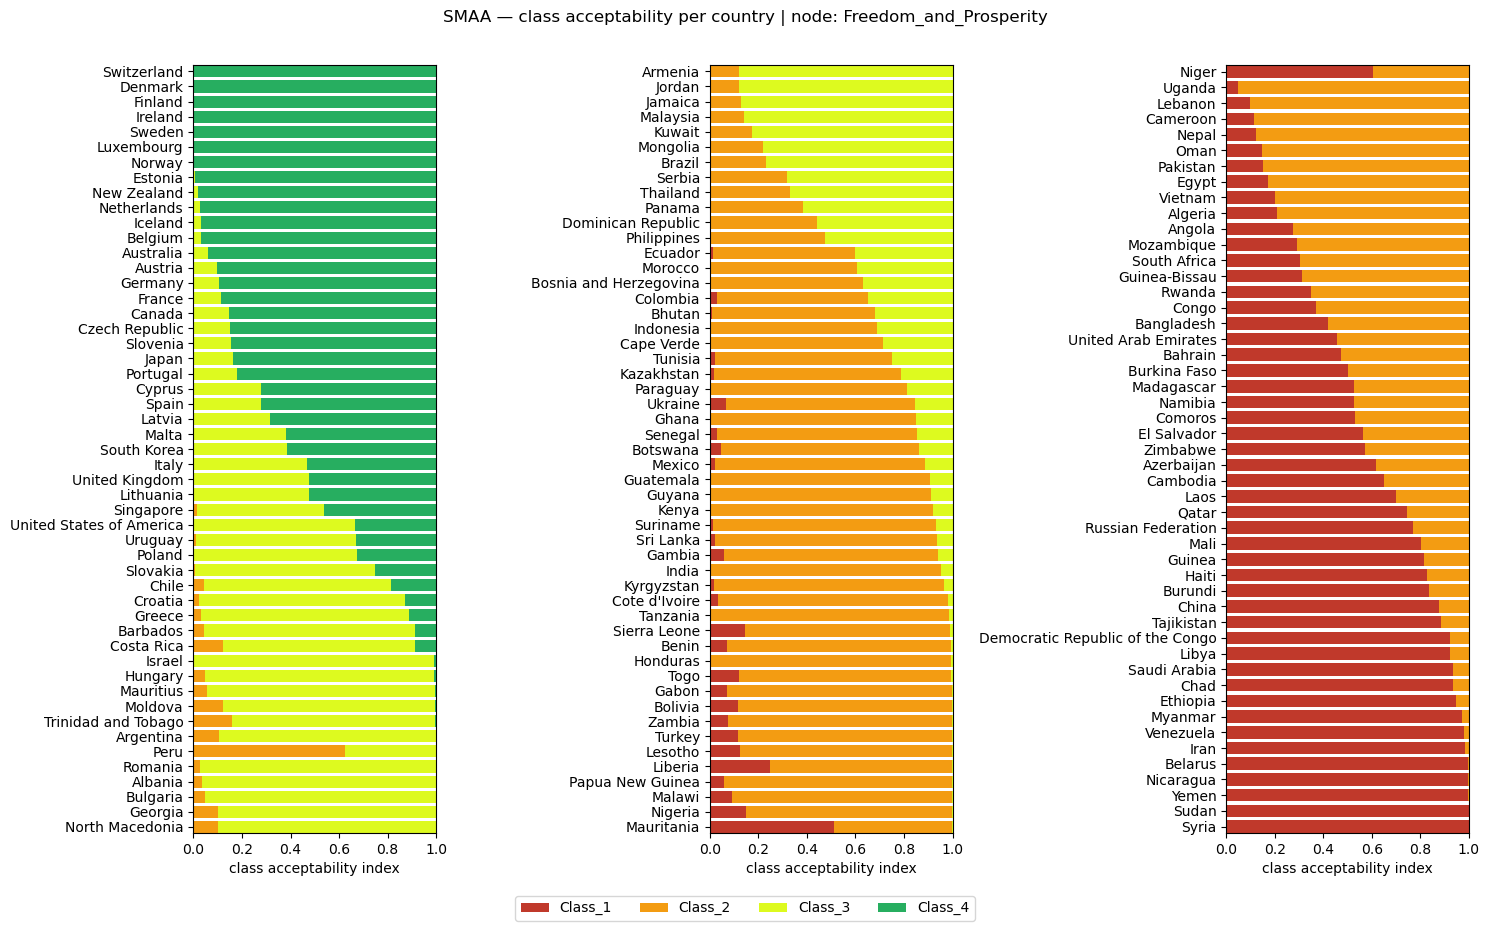

In [163]:
plot_acceptability_smaa(acceptability_fp, categories, colors, "Freedom_and_Prosperity")

In [39]:
plot_country_pies_smaa(acceptability_fp, nodes, categories, colors, "Brazil")

NameError: name 'acceptability_fp' is not defined